In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
df = pd.read_csv('data/train.csv')
df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [42]:
df.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


In [44]:
numeric_cols = df.select_dtypes(include='number')
numeric_cols = numeric_cols.drop('id', axis=1).columns
numeric_cols

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed',
       'rainfall'],
      dtype='object')

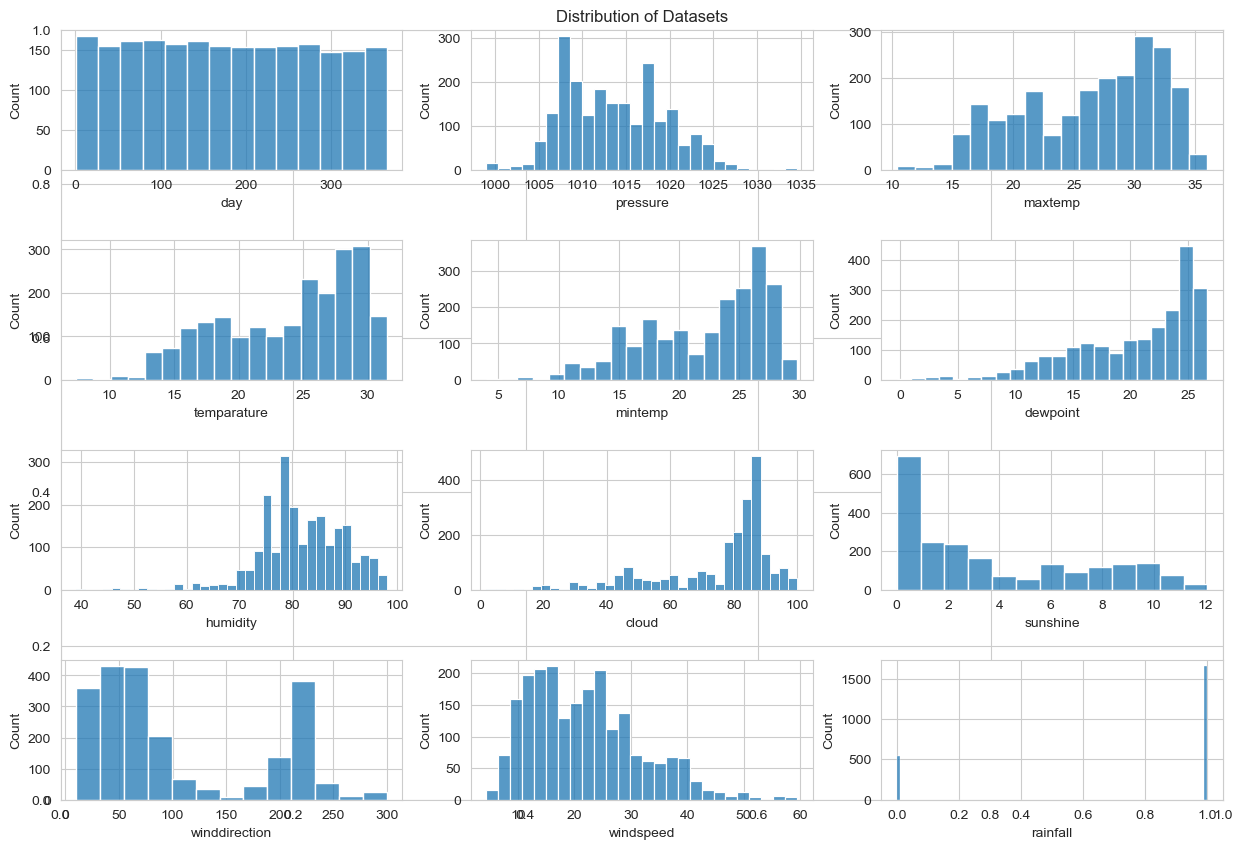

In [45]:
plt.figure(figsize=(15,10))
plt.subplots_adjust(hspace=0.5)

plt.title('Distribution of Datasets')
for i, col in enumerate(numeric_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col])


plt.show()

<Axes: >

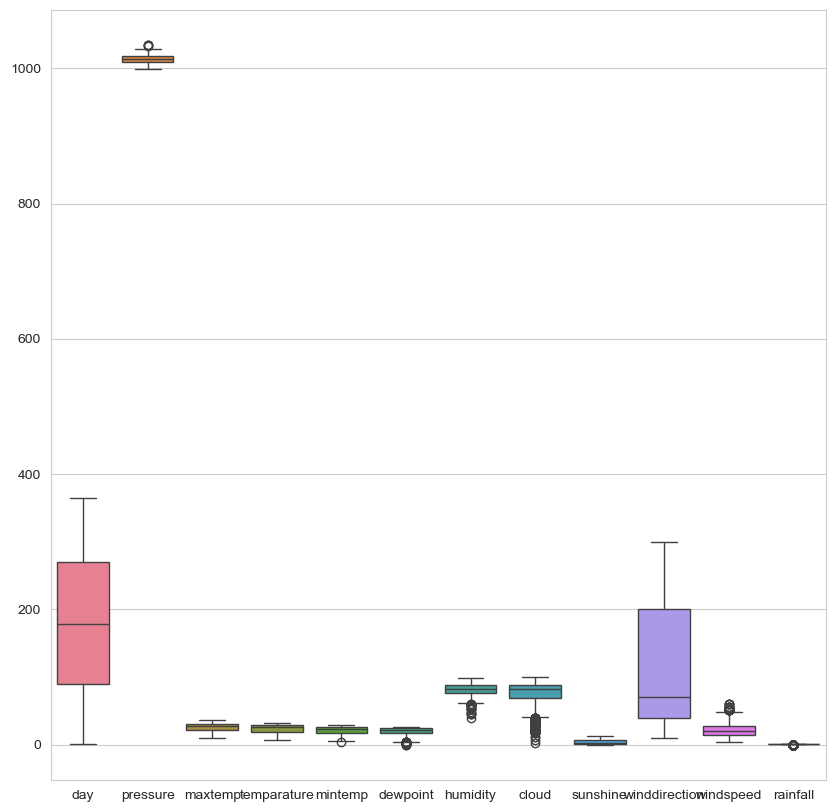

In [46]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df[numeric_cols])

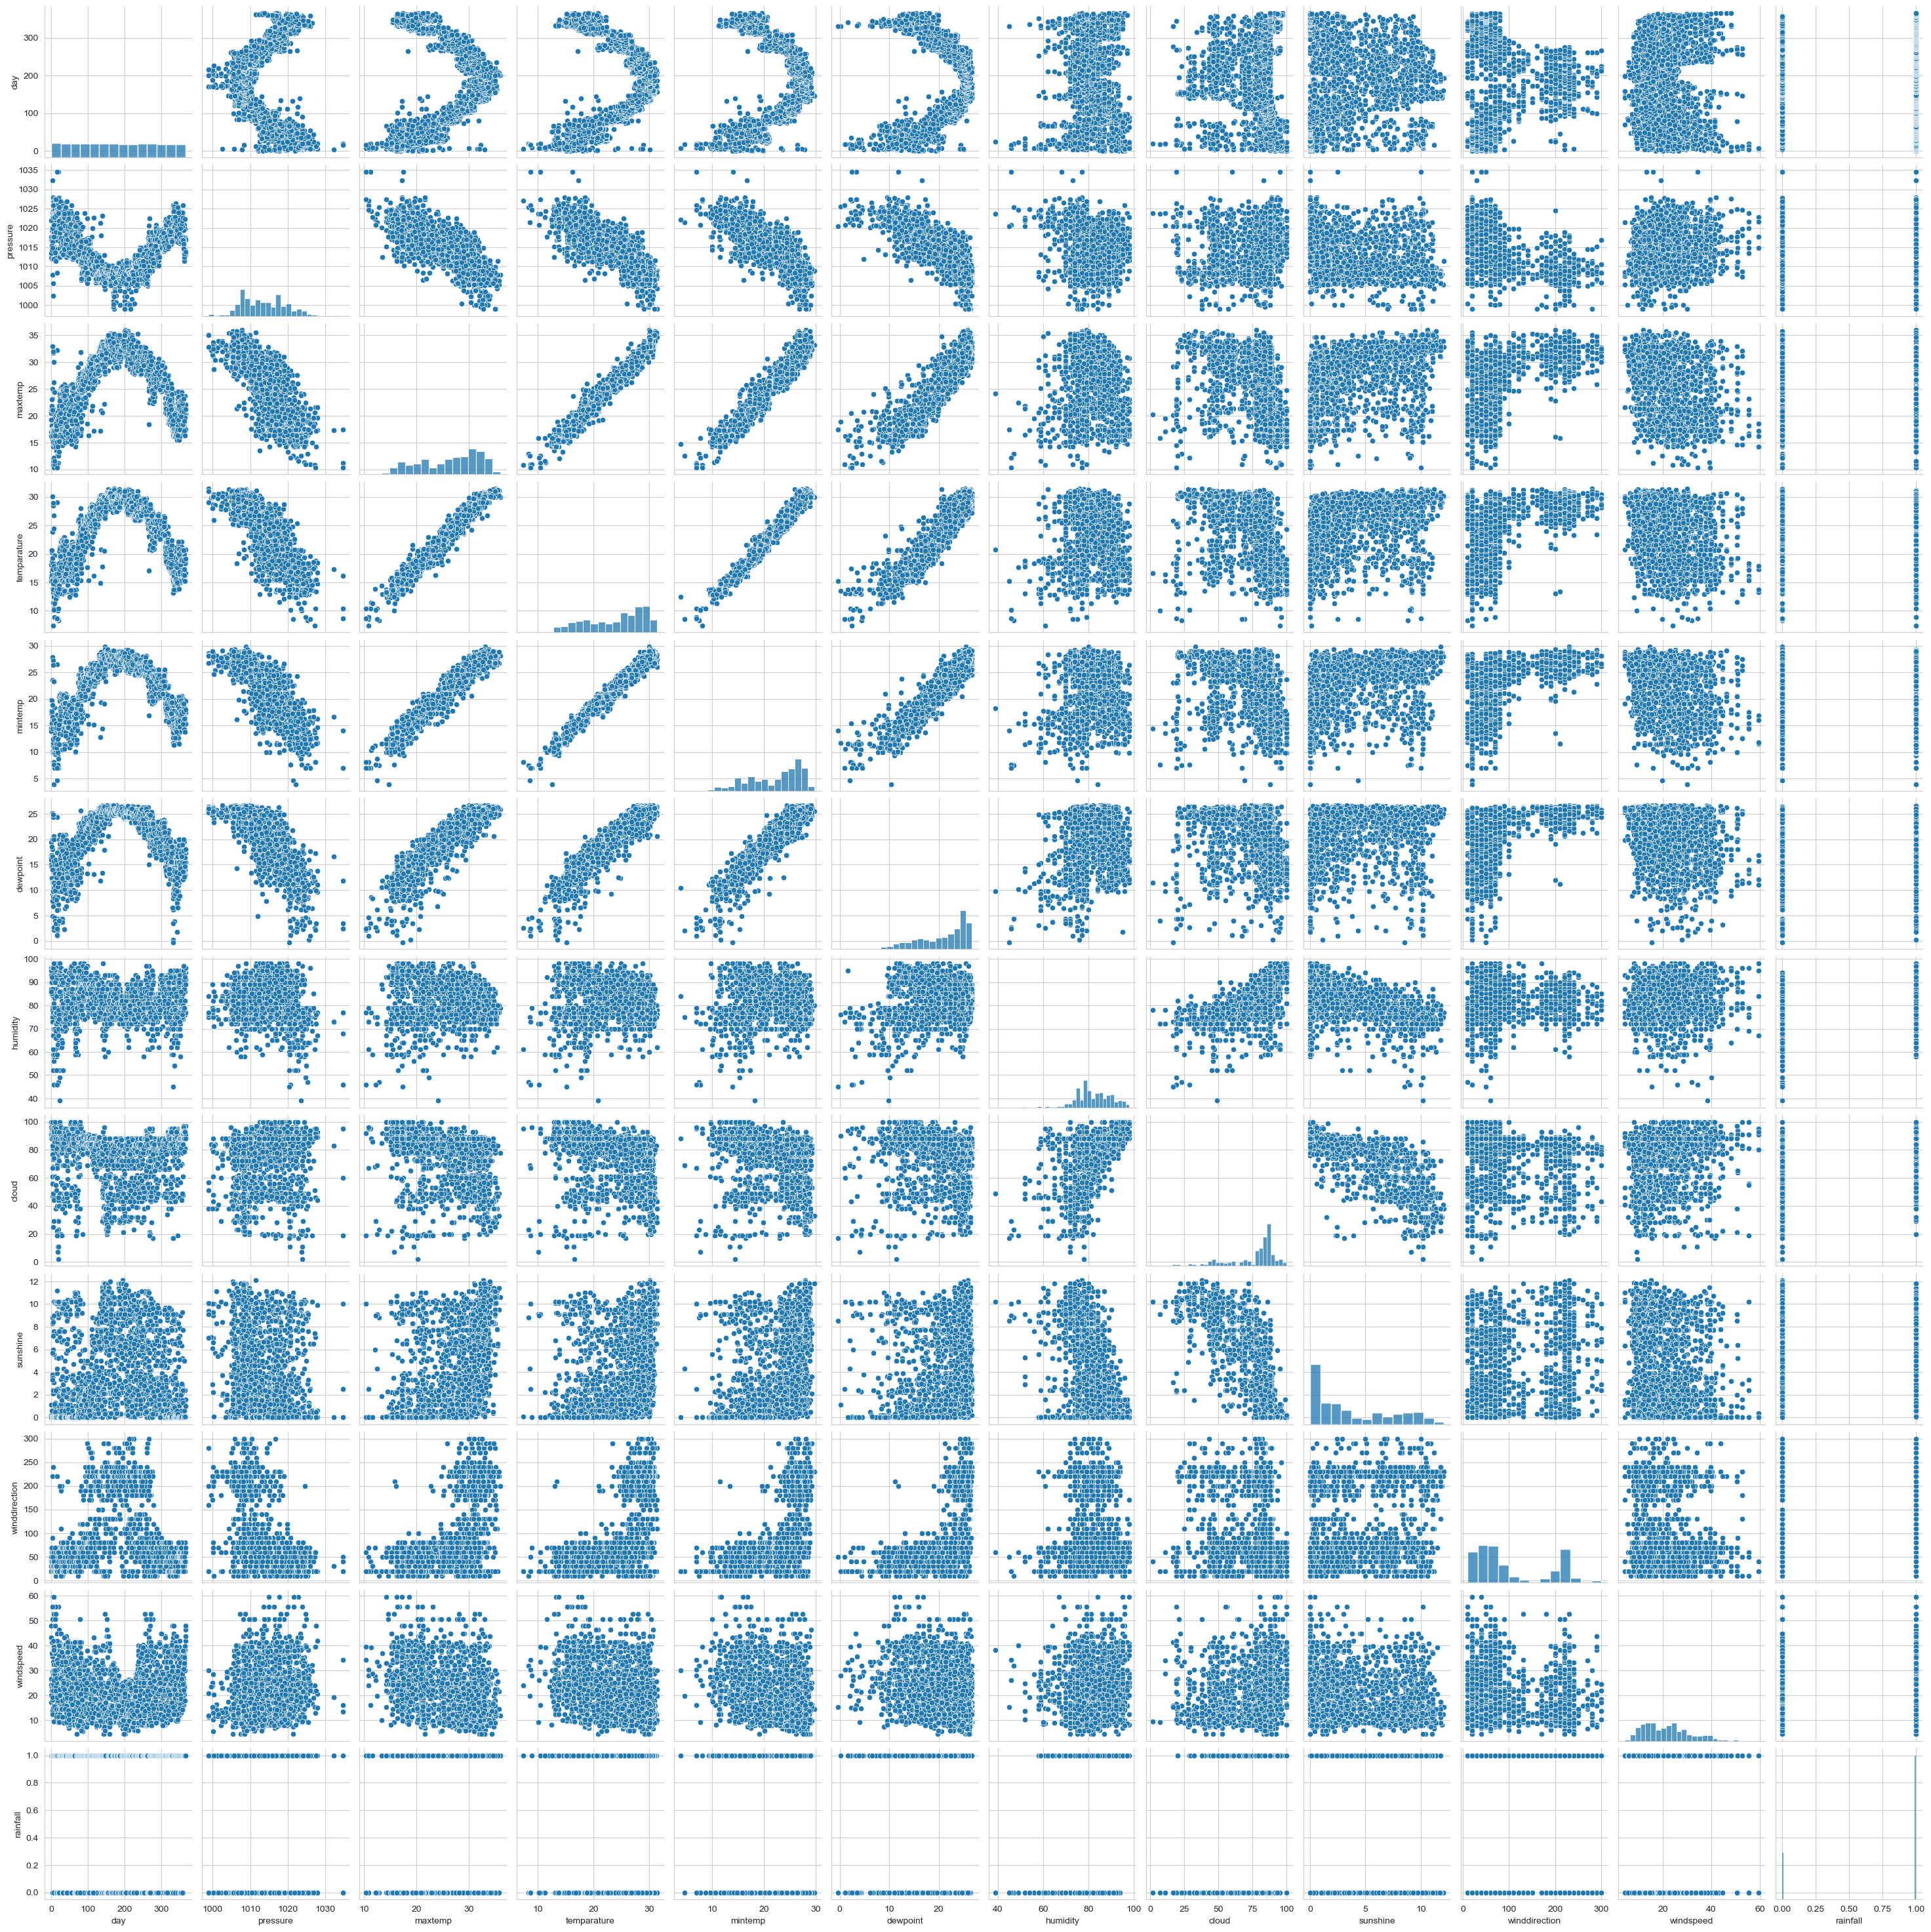

In [47]:
sns.pairplot(df[numeric_cols])

<Axes: >

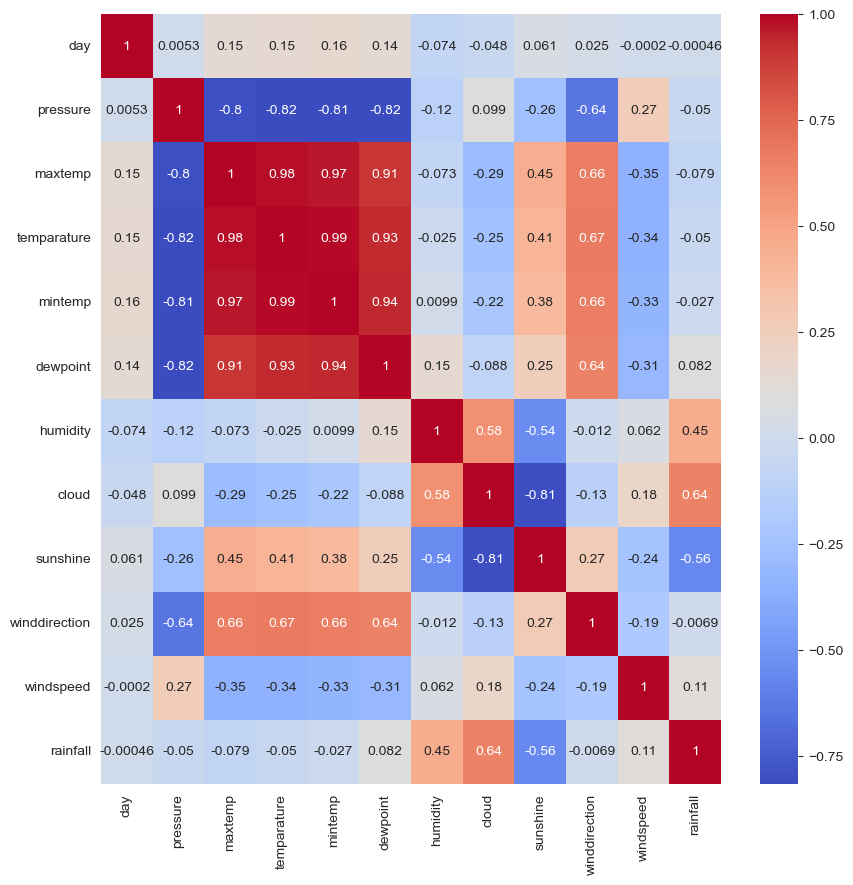

In [48]:
plt.figure(figsize=(10,10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')

In [49]:
print(df[numeric_cols].corr())

                    day  pressure   maxtemp  temparature   mintemp  dewpoint  \
day            1.000000  0.005337  0.146294     0.153590  0.161475  0.137929   
pressure       0.005337  1.000000 -0.800499    -0.816531 -0.814453 -0.817008   
maxtemp        0.146294 -0.800499  1.000000     0.982932  0.965529  0.906703   
temparature    0.153590 -0.816531  0.982932     1.000000  0.987150  0.933617   
mintemp        0.161475 -0.814453  0.965529     0.987150  1.000000  0.941342   
dewpoint       0.137929 -0.817008  0.906703     0.933617  0.941342  1.000000   
humidity      -0.074048 -0.119949 -0.072615    -0.025016  0.009891  0.153390   
cloud         -0.048175  0.098600 -0.289047    -0.249355 -0.219399 -0.088446   
sunshine       0.060936 -0.257163  0.452387     0.414019  0.379497  0.249676   
winddirection  0.024800 -0.643293  0.662235     0.668963  0.663828  0.643073   
windspeed     -0.000199  0.266012 -0.354168    -0.342262 -0.328871 -0.312179   
rainfall      -0.000462 -0.049886 -0.079

In [50]:
print(df['rainfall'].value_counts())

rainfall
1    1650
0     540
Name: count, dtype: int64


In [51]:
df.isna().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [52]:
df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


In [53]:
X = df.drop(columns=['rainfall', 'id'])
y = df['rainfall']

#### Modelling

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [55]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

dc = DummyClassifier(strategy='most_frequent')
dc.fit(X_train, y_train)

dc_pred = dc.predict(X_test)
print(confusion_matrix(y_test, dc_pred))
print(classification_report(y_test, dc_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, dc_pred)}")

[[  0 167]
 [  0 490]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       167
           1       0.75      1.00      0.85       490

    accuracy                           0.75       657
   macro avg       0.37      0.50      0.43       657
weighted avg       0.56      0.75      0.64       657

ROC-AUC Score: 0.5


/Users/adetsi/miniforge3/envs/kaggle/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adetsi/miniforge3/envs/kaggle/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/adetsi/miniforge3/envs/kaggle/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

In [56]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print(confusion_matrix(lr_pred, y_test))
print((classification_report(y_test, lr_pred)))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_pred)}")

[[121  65]
 [ 46 425]]
              precision    recall  f1-score   support

           0       0.65      0.72      0.69       167
           1       0.90      0.87      0.88       490

    accuracy                           0.83       657
   macro avg       0.78      0.80      0.79       657
weighted avg       0.84      0.83      0.83       657

ROC-AUC Score: 0.7959489184895516


/Users/adetsi/miniforge3/envs/kaggle/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print(confusion_matrix(rf_pred, y_test))
print((classification_report(y_test, rf_pred)))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_pred)}")

[[104  28]
 [ 63 462]]
              precision    recall  f1-score   support

           0       0.79      0.62      0.70       167
           1       0.88      0.94      0.91       490

    accuracy                           0.86       657
   macro avg       0.83      0.78      0.80       657
weighted avg       0.86      0.86      0.86       657

ROC-AUC Score: 0.7828058169375534


In [58]:
import xgboost as xgb

xbg = xgb.XGBClassifier(class_weight='balanced', random_state=42)
xbg.fit(X_train, y_train)

xgb_pred = xbg.predict(X_test)
print(confusion_matrix(xgb_pred, y_test))
print((classification_report(y_test, xgb_pred)))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_pred)}")

[[ 97  33]
 [ 70 457]]
              precision    recall  f1-score   support

           0       0.75      0.58      0.65       167
           1       0.87      0.93      0.90       490

    accuracy                           0.84       657
   macro avg       0.81      0.76      0.78       657
weighted avg       0.84      0.84      0.84       657

ROC-AUC Score: 0.7567456922888915


/Users/adetsi/miniforge3/envs/kaggle/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [22:25:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [59]:
from lightgbm import LGBMClassifier

lightgbm = LGBMClassifier(class_weight='balanced', random_state=42)
lightgbm.fit(X_train, y_train)

lightgbm_pred = lightgbm.predict(X_test)
print(confusion_matrix(lightgbm_pred, y_test))
print((classification_report(y_test, lightgbm_pred)))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lightgbm_pred)}")

[LightGBM] [Info] Number of positive: 1160, number of negative: 373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1504
[LightGBM] [Info] Number of data points in the train set: 1533, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[[104  41]
 [ 63 449]]
              precision    recall  f1-score   support

           0       0.72      0.62      0.67       167
           1       0.88      0.92      0.90       490

    accuracy                           0.84       657
   macro avg       0.80      0.77      0.78       657
weighted avg       0.84      0.84      0.84       657

ROC-AUC Score: 0.7695405108151046


In [60]:
from sklearn.svm import SVC

svc = SVC(class_weight='balanced', random_state=42, kernel='rbf', probability=True)
svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)
print(confusion_matrix(svc_pred, y_test))
print((classification_report(y_test, svc_pred)))
print(f"ROC-AUC Score: {roc_auc_score(y_test, svc_pred)}")

[[104  32]
 [ 63 458]]
              precision    recall  f1-score   support

           0       0.76      0.62      0.69       167
           1       0.88      0.93      0.91       490

    accuracy                           0.86       657
   macro avg       0.82      0.78      0.80       657
weighted avg       0.85      0.86      0.85       657

ROC-AUC Score: 0.7787241842844922


In [61]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
print(confusion_matrix(knn_pred, y_test))
print((classification_report(y_test, knn_pred)))
print(f"ROC-AUC Score: {roc_auc_score(y_test, knn_pred)}")

[[ 89  26]
 [ 78 464]]
              precision    recall  f1-score   support

           0       0.77      0.53      0.63       167
           1       0.86      0.95      0.90       490

    accuracy                           0.84       657
   macro avg       0.82      0.74      0.77       657
weighted avg       0.84      0.84      0.83       657

ROC-AUC Score: 0.7399364536233656


In [62]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)
print(confusion_matrix(nb_pred, y_test))
print((classification_report(y_test, nb_pred)))
print(f"ROC-AUC Score: {roc_auc_score(y_test, nb_pred)}")

[[119  54]
 [ 48 436]]
              precision    recall  f1-score   support

           0       0.69      0.71      0.70       167
           1       0.90      0.89      0.90       490

    accuracy                           0.84       657
   macro avg       0.79      0.80      0.80       657
weighted avg       0.85      0.84      0.85       657

ROC-AUC Score: 0.801185384333374


In [63]:
from imblearn.over_sampling import SMOTE
import numpy as np

In [64]:
smote = SMOTE(random_state=42)  # Random state for reproducibility
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After SMOTE:", dict(zip(*np.unique(y_train_smote, return_counts=True))))

Before SMOTE: {np.int64(0): np.int64(373), np.int64(1): np.int64(1160)}
After SMOTE: {np.int64(0): np.int64(1160), np.int64(1): np.int64(1160)}


In [65]:
nb = GaussianNB()
nb.fit(X_train_smote, y_train_smote)

GaussianNB()

In [66]:
nb_pred = nb.predict(X_test)
print(confusion_matrix(nb_pred, y_test))
print((classification_report(y_test, nb_pred)))
print(f"ROC-AUC Score: {roc_auc_score(y_test, nb_pred)}")


[[125  80]
 [ 42 410]]
              precision    recall  f1-score   support

           0       0.61      0.75      0.67       167
           1       0.91      0.84      0.87       490

    accuracy                           0.81       657
   macro avg       0.76      0.79      0.77       657
weighted avg       0.83      0.81      0.82       657

ROC-AUC Score: 0.7926188439447636


In [67]:
type(y_train_smote)

pandas.core.series.Series

In [68]:
type(X_train_smote)

pandas.core.frame.DataFrame

In [69]:
y_train_smote.value_counts()

rainfall
1    1160
0    1160
Name: count, dtype: int64

<Axes: xlabel='rainfall', ylabel='count'>

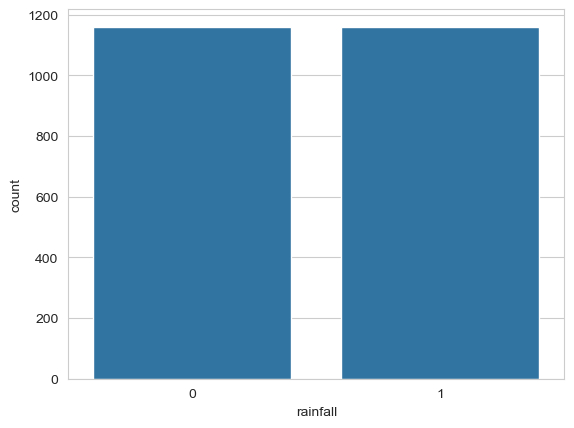

In [70]:
sns.barplot(y_train_smote.value_counts())

In [71]:
y_train.value_counts()

rainfall
1    1160
0     373
Name: count, dtype: int64